# SIGCSE Problem Framing Analysis

This notebook reproduces the descriptive analysis for the SIGCSE poster extended abstract on unaided data science problem-framing drafts.

It performs five checks:

1. Load the raw submission export.
2. Filter the conservative unaided subset.
3. Load the binary component coding.
4. Reproduce draft-level and participant-level component counts.
5. Recompute inter-rater agreement from the coding workbook and regenerate the component-presence figure.


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
DATA_DIR = ROOT / 'data'
RESULTS_DIR = ROOT / 'results'
FIG_DIR = ROOT / 'figures'

RAW_CSV = DATA_DIR / 'submissions_2026-06-29.csv'
CODING_XLSX = DATA_DIR / 'problem_framing_coding_sheet.xlsx'
RESOLVED_CODES = DATA_DIR / 'resolved_component_codes.csv'

components = [
    'Data/features',
    'Aligned problem',
    'Analytic objective',
    'Method/model',
    'Explicit constraints',
    'Stakeholder/action',
    'Success criteria',
    'Ethics/privacy/fairness',
]

scenario_components = ['Data/features']
prompt_named_components = ['Aligned problem', 'Analytic objective', 'Method/model', 'Explicit constraints', 'Success criteria']
extended_components = ['Stakeholder/action', 'Ethics/privacy/fairness']

## 1. Load the raw submission export and filter the unaided subset

The poster uses a conservative activity-based filter. A draft is retained only when no scaffold suggestion was recorded as shown and none was recorded as accepted.


In [2]:
raw = pd.read_csv(RAW_CSV)
unaided = raw[
    (raw['ai_suggestions_shown'].fillna(0).astype(int) == 0) &
    (raw['ai_suggestions_accepted'].fillna(0).astype(int) == 0)
].copy()

summary = {
    'raw_rows': len(raw),
    'unaided_rows': len(unaided),
    'raw_sessions': raw['session_id'].nunique(),
    'unaided_sessions': unaided['session_id'].nunique(),
    'beginner_drafts': int((unaided['expertise_level'] == 'beginner').sum()),
    'intermediate_drafts': int((unaided['expertise_level'] == 'intermediate').sum()),
    'advanced_drafts': int((unaided['expertise_level'] == 'advanced').sum()),
    'word_min': int(unaided['word_count'].min()),
    'word_mean': round(float(unaided['word_count'].mean()), 1),
    'word_median': float(unaided['word_count'].median()),
    'word_max': int(unaided['word_count'].max()),
    'time_min_seconds': int(unaided['time_spent_seconds'].min()),
    'time_median_seconds': float(unaided['time_spent_seconds'].median()),
    'time_max_seconds': int(unaided['time_spent_seconds'].max()),
    'revision_min': int(unaided['revision_count'].min()),
    'revision_max': int(unaided['revision_count'].max()),
}
summary

{'raw_rows': 39,
 'unaided_rows': 26,
 'raw_sessions': 19,
 'unaided_sessions': 19,
 'beginner_drafts': 2,
 'intermediate_drafts': 13,
 'advanced_drafts': 11,
 'word_min': 20,
 'word_mean': 81.2,
 'word_median': 60.5,
 'word_max': 225,
 'time_min_seconds': 7,
 'time_median_seconds': 155.5,
 'time_max_seconds': 1064,
 'revision_min': 0,
 'revision_max': 83}

In [3]:
# Export the filtered subset for transparency.
RESULTS_DIR.mkdir(exist_ok=True)
unaided.to_csv(DATA_DIR / 'unaided_submissions_filtered.csv', index=False)
unaided[['session_id', 'expertise_level', 'word_count', 'revision_count', 'time_spent_seconds', 'content']].head()


,session_id,expertise_level,word_count,revision_count,time_spent_seconds,content
1,0953347c-6e38-476c-b913-39d92190a309,intermediate,46,1,38,Build a classification model to predict whethe...
3,df7cca9d-72c1-47db-8a4a-991679343054,advanced,45,2,85,Develop a predictive machine learning model th...
5,f3470f6c-60d2-4353-b29b-e77aebb474a9,beginner,29,17,126,Context: Student don't often complete the cour...
7,738f9aec-71c7-4f41-ba4b-0ce304c5fa7d,advanced,82,23,249,"We hav Student data from different course , re..."
9,86e95e46-64cc-4da9-9129-5f9f27e64a84,beginner,29,10,184,For me personally I think distraction and lack...


## 2. Load resolved component codes

The resolved code file contains one row per unaided draft and eight binary component codes.


In [4]:
codes = pd.read_csv(RESOLVED_CODES)
for c in components:
    codes[c] = codes[c].astype(int)

codes['draft_num'] = codes['Draft'].str.extract(r'(\d+)').astype(int)
print(codes.shape)
codes[['Draft','User','Expertise','Words'] + components].head()


(26, 16)


,Draft,User,Expertise,Words,Data/features,Aligned problem,Analytic objective,Method/model,Explicit constraints,Stakeholder/action,Success criteria,Ethics/privacy/fairness
0,D01,User 1,intermediate,92,0,0,0,0,0,0,0,0
1,D02,User 2,intermediate,46,0,0,0,0,0,0,0,0
2,D03,User 3,advanced,90,0,0,0,0,0,0,0,0
3,D04,User 3,advanced,181,0,0,0,0,0,0,0,0
4,D05,User 4,advanced,132,1,1,1,1,1,0,0,1


## 3. Reproduce draft-level and participant-level counts

Participant-level counts use the longest unaided draft for each user. Ties are broken by the later draft identifier.


In [5]:
participant_codes = (
    codes.sort_values(['User', 'Words', 'draft_num'], ascending=[True, False, False])
         .drop_duplicates('User', keep='first')
         .copy()
)

rows = []
for c in components:
    draft_count = int(codes[c].sum())
    participant_count = int(participant_codes[c].sum())
    rows.append({
        'component': c,
        'draft_count': draft_count,
        'draft_n': len(codes),
        'draft_pct': 100 * draft_count / len(codes),
        'participant_count': participant_count,
        'participant_n': len(participant_codes),
        'participant_pct': 100 * participant_count / len(participant_codes),
    })

component_summary = pd.DataFrame(rows)
component_summary.to_csv(RESULTS_DIR / 'component_presence_summary.csv', index=False)
component_summary


,component,draft_count,draft_n,draft_pct,participant_count,participant_n,participant_pct
0,Data/features,13,26,50.000000,9,19,47.368421
1,Aligned problem,12,26,46.153846,8,19,42.105263
2,Analytic objective,11,26,42.307692,8,19,42.105263
3,Method/model,10,26,38.461538,7,19,36.842105
4,Explicit constraints,6,26,23.076923,4,19,21.052632
5,Stakeholder/action,6,26,23.076923,4,19,21.052632
6,Success criteria,5,26,19.230769,3,19,15.789474
7,Ethics/privacy/fairness,3,26,11.538462,2,19,10.526316


In [6]:
participant_codes[['Draft','User','Expertise','Words'] + components]


,Draft,User,Expertise,Words,Data/features,Aligned problem,Analytic objective,Method/model,Explicit constraints,Stakeholder/action,Success criteria,Ethics/privacy/fairness
0,D01,User 1,intermediate,92,0,0,0,0,0,0,0,0
13,D14,User 10,advanced,82,0,0,0,0,0,0,0,0
14,D15,User 11,beginner,29,0,0,0,0,0,0,0,0
16,D17,User 12,intermediate,22,1,0,0,0,0,0,0,0
17,D18,User 13,advanced,21,0,1,1,1,0,0,0,0
18,D19,User 14,advanced,58,1,1,1,0,1,0,1,0
19,D20,User 15,intermediate,74,1,1,1,1,0,1,0,0
21,D22,User 16,intermediate,122,1,1,1,1,1,1,1,0
22,D23,User 17,advanced,45,0,0,0,0,0,0,0,0
24,D25,User 18,intermediate,132,0,0,0,0,0,0,0,0


## 4. Recompute inter-rater agreement

This step reads the `Rater 1` and `Rater 2` tabs in the coding workbook, aligns the 15 coded drafts by draft ID, and computes percent agreement and Cohen's kappa manually.


In [7]:
def load_rater(sheet_name):
    df = pd.read_excel(CODING_XLSX, sheet_name=sheet_name)
    df = df[df['Draft'].astype(str).str.match(r'^D\d{2}$', na=False)].copy()
    df = df.set_index('Draft')
    return df

r1 = load_rater('Rater 1')
r2 = load_rater('Rater 2')
common = sorted(set(r1.index) & set(r2.index), key=lambda x: int(x[1:]))
r1 = r1.loc[common]
r2 = r2.loc[common]

y1 = r1[components].astype(int).to_numpy().ravel()
y2 = r2[components].astype(int).to_numpy().ravel()

po = float((y1 == y2).mean())
p1 = y1.mean()
p2 = y2.mean()
pe = p1 * p2 + (1 - p1) * (1 - p2)
kappa = (po - pe) / (1 - pe)

agreement = pd.DataFrame([{
    'decisions': len(y1),
    'agreement_pct': 100 * po,
    'cohens_kappa': kappa,
    'both_1': int(((y1 == 1) & (y2 == 1)).sum()),
    'r1_1_r2_0': int(((y1 == 1) & (y2 == 0)).sum()),
    'r1_0_r2_1': int(((y1 == 0) & (y2 == 1)).sum()),
    'both_0': int(((y1 == 0) & (y2 == 0)).sum()),
}])
agreement.to_csv(RESULTS_DIR / 'inter_rater_agreement.csv', index=False)
agreement


,decisions,agreement_pct,cohens_kappa,both_1,r1_1_r2_0,r1_0_r2_1,both_0
0,208,100.0,1.0,66,0,0,142


In [8]:
# Show the exact cells where raters disagreed.
disagreements = []
for draft in common:
    for c in components:
        if int(r1.loc[draft, c]) != int(r2.loc[draft, c]):
            disagreements.append({
                'Draft': draft,
                'User': r2.loc[draft, 'User'],
                'component': c,
                'Rater 1': int(r1.loc[draft, c]),
                'Rater 2': int(r2.loc[draft, c]),
                'Draft text': r2.loc[draft, 'Draft text'],
            })

disagreement_df = pd.DataFrame(disagreements)
disagreement_df.to_csv(RESULTS_DIR / 'coding_disagreements.csv', index=False)
disagreement_df


""


## 5. Regenerate the component-presence figure

The figure separates the single scenario-derived data component, the five prompt-named facets, and the two extended responsible-framing indicators.


PosixPath('../figures/component_presence_reproduced.png')

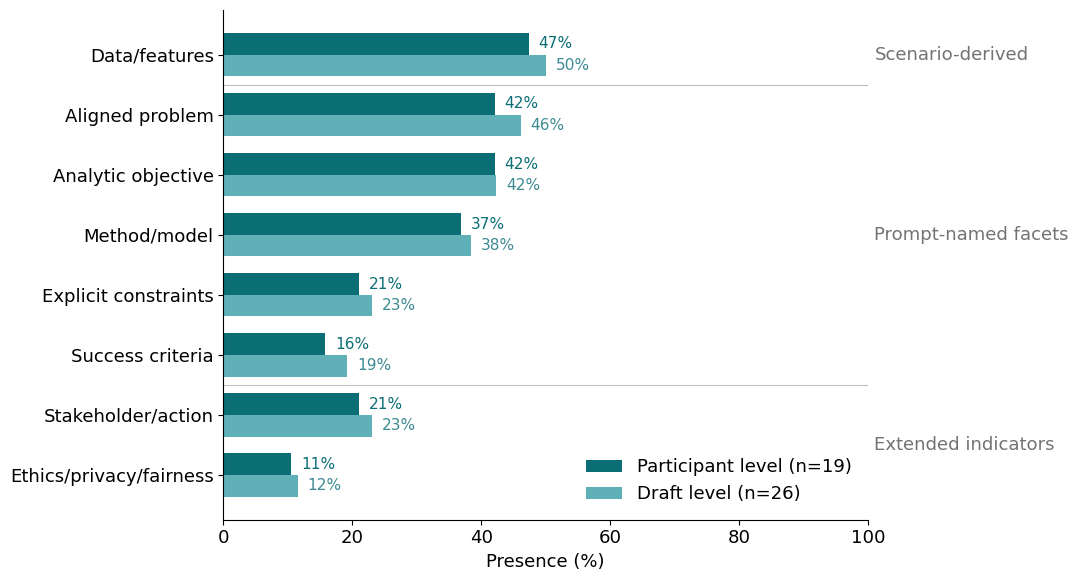

In [9]:
# Plot order and labels used in the manuscript figure.
plot_order = [
    'Data/features','Aligned problem','Analytic objective','Method/model',
    'Explicit constraints','Success criteria','Stakeholder/action','Ethics/privacy/fairness',
]
labels = list(plot_order)

plot_df = component_summary.set_index('component').loc[plot_order].reset_index()
y = np.arange(len(plot_df))
height = 0.36

n_participants = int(plot_df['participant_n'].iloc[0])
n_drafts = int(plot_df['draft_n'].iloc[0])

PC = '#0B6E75'   # participant level (primary)
DC = '#5FB0B7'   # draft level (transparency check)
LBL = '#3C8A92'  # readable label for the lighter bars

plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(y - height/2, plot_df['participant_pct'], height, color=PC, label=f'Participant level (n={n_participants})')
ax.barh(y + height/2, plot_df['draft_pct'], height, color=DC, label=f'Draft level (n={n_drafts})')
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('Presence (%)')
ax.legend(frameon=False, loc='lower right')
ax.spines[['top','right']].set_visible(False)

ax.axhline(0.5, color='0.75', linewidth=0.8)
ax.axhline(5.5, color='0.75', linewidth=0.8)
ax.text(101, 0, 'Scenario-derived', va='center', color='0.45')
ax.text(101, 3, 'Prompt-named facets', va='center', color='0.45')
ax.text(101, 6.5, 'Extended indicators', va='center', color='0.45')

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row['participant_pct'] + 1.5, i - height/2, f"{row['participant_pct']:.0f}%", va='center', color=PC, fontsize=11)
    ax.text(row['draft_pct'] + 1.5, i + height/2, f"{row['draft_pct']:.0f}%", va='center', color=LBL, fontsize=11)

fig.tight_layout()
FIG_DIR.mkdir(exist_ok=True)
out = FIG_DIR / 'component_presence_reproduced.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
out

## 6. Manuscript-ready values

These are the manuscript values reproduced by the notebook.


In [10]:
print(f"Unaided subset: {len(unaided)} drafts from {unaided['session_id'].nunique()} sessions")
print(f"Draft expertise split: {(unaided['expertise_level']=='beginner').sum()} beginner / {(unaided['expertise_level']=='intermediate').sum()} intermediate / {(unaided['expertise_level']=='advanced').sum()} advanced")
print(f"Participant expertise split from coded drafts: {(participant_codes['Expertise']=='beginner').sum()} beginner / {(participant_codes['Expertise']=='intermediate').sum()} intermediate / {(participant_codes['Expertise']=='advanced').sum()} advanced")
print(f"Word count range: {unaided['word_count'].min()}–{unaided['word_count'].max()}, mean {unaided['word_count'].mean():.1f}, median {unaided['word_count'].median():.0f}")
print(f"Time range: {unaided['time_spent_seconds'].min()}–{unaided['time_spent_seconds'].max()} seconds, median {unaided['time_spent_seconds'].median():.0f}")
print(f"Revision range: {unaided['revision_count'].min()}–{unaided['revision_count'].max()}")
print(f"Agreement: {agreement.loc[0,'agreement_pct']:.1f}% across {int(agreement.loc[0,'decisions'])} decisions; Cohen's kappa = {agreement.loc[0,'cohens_kappa']:.2f}")
component_summary[['component','participant_count','participant_n','participant_pct','draft_count','draft_n','draft_pct']]

Unaided subset: 26 drafts from 19 sessions
Draft expertise split: 2 beginner / 13 intermediate / 11 advanced
Participant expertise split from coded drafts: 2 beginner / 9 intermediate / 8 advanced
Word count range: 20–225, mean 81.2, median 60
Time range: 7–1064 seconds, median 156
Revision range: 0–83
Agreement: 100.0% across 208 decisions; Cohen's kappa = 1.00


,component,participant_count,participant_n,participant_pct,draft_count,draft_n,draft_pct
0,Data/features,9,19,47.368421,13,26,50.000000
1,Aligned problem,8,19,42.105263,12,26,46.153846
2,Analytic objective,8,19,42.105263,11,26,42.307692
3,Method/model,7,19,36.842105,10,26,38.461538
4,Explicit constraints,4,19,21.052632,6,26,23.076923
5,Stakeholder/action,4,19,21.052632,6,26,23.076923
6,Success criteria,3,19,15.789474,5,26,19.230769
7,Ethics/privacy/fairness,2,19,10.526316,3,26,11.538462
